**importing modules**

In [1]:
import matplotlib.pyplot as plt
import numpy as numpy
import pandas as pd

**taking the dataset**

In [12]:
df = pd.read_csv('netflix_titles.csv')

df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


**Cleaning the data**

In [3]:
df = df.dropna(subset=['type','release_year','rating','country','duration']) 
#subsets are those, which we need in our analysis



**TV vs Movie shows number comparison**

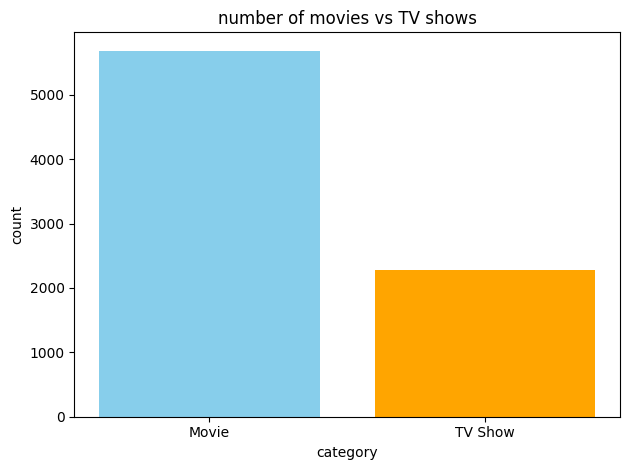

In [4]:
type_counts = df['type'].value_counts()

plt.bar(type_counts.index, type_counts.values, color=['skyblue','orange'])

plt.title('number of movies vs TV shows')
plt.xlabel('category')
plt.ylabel('count')
plt.tight_layout()

plt.savefig('number of tvshows vs movies.png')
plt.show()

**Shows rating comparison**

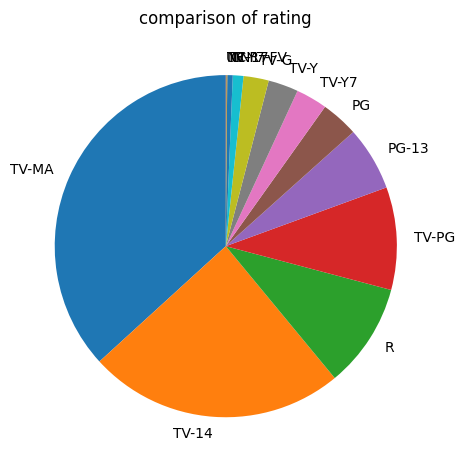

In [5]:
rating_counts = df['rating'].value_counts()

plt.pie(rating_counts,labels=rating_counts.index,startangle = 90)

plt.title('comparison of rating')
plt.tight_layout()

plt.savefig('rating comparison pie chart')
plt.show()

**Movie Duration Histogram**

In [6]:
# taking movie as a dataframe

movie_df = df[df['type']=='Movie'].copy()

print(movie_df.head(5))

   show_id   type                 title             director  \
0       s1  Movie  Dick Johnson Is Dead      Kirsten Johnson   
7       s8  Movie               Sankofa         Haile Gerima   
9      s10  Movie          The Starling       Theodore Melfi   
12     s13  Movie          Je Suis Karl  Christian Schwochow   
24     s25  Movie                 Jeans           S. Shankar   

                                                 cast  \
0                                                 NaN   
7   Kofi Ghanaba, Oyafunmike Ogunlano, Alexandra D...   
9   Melissa McCarthy, Chris O'Dowd, Kevin Kline, T...   
12  Luna Wedler, Jannis Niewöhner, Milan Peschel, ...   
24  Prashanth, Aishwarya Rai Bachchan, Sri Lakshmi...   

                                              country          date_added  \
0                                       United States  September 25, 2021   
7   United States, Ghana, Burkina Faso, United Kin...  September 24, 2021   
9                                       U

In [7]:
movie_df['duration_int'] = movie_df['duration'].str.replace(' min','').astype(int)

#

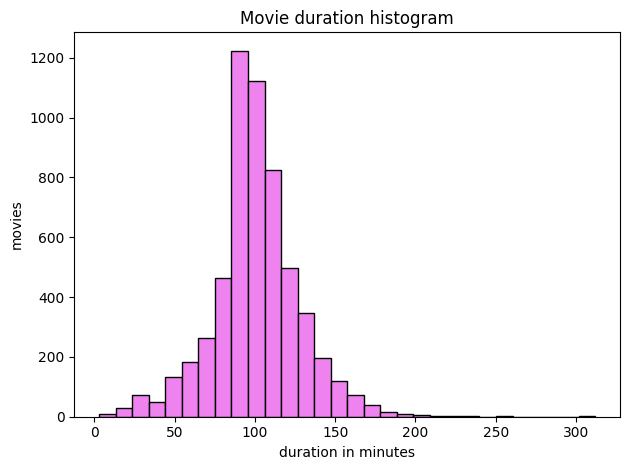

In [8]:
# plotting the histogram

plt.hist(movie_df['duration_int'], bins=30, color='violet',edgecolor='black')

plt.title('Movie duration histogram')
plt.xlabel('duration in minutes')
plt.ylabel('movies')
plt.tight_layout()

plt.savefig('movie duration histogram.png')
plt.show()

**Release year vs shows count**

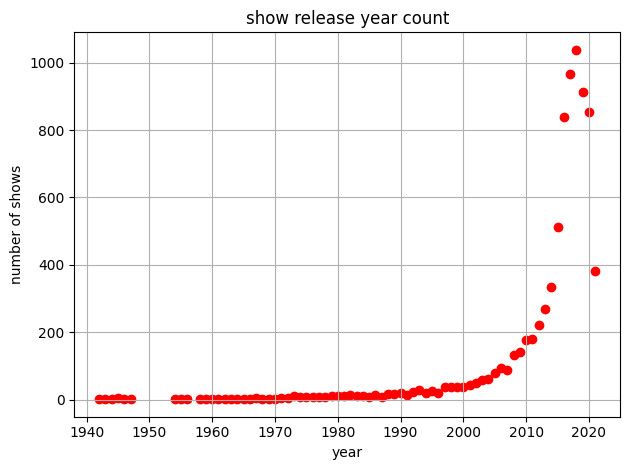

In [9]:
release_year_count = df['release_year'].value_counts()

plt.scatter(release_year_count.index,release_year_count.values,color='red')

plt.title('show release year count')
plt.xlabel('year')
plt.ylabel('number of shows')
plt.grid(True)
plt.tight_layout()
plt.savefig('Release_year vs shows count scatterplot.png')
plt.show()

**Country wise show release**

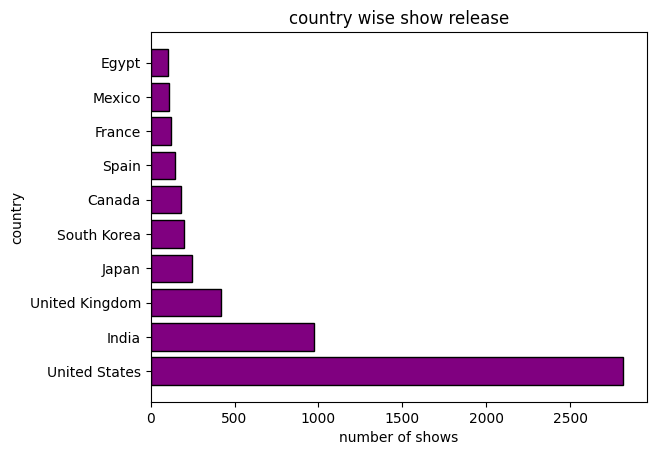

In [10]:
country_counts = df['country'].value_counts().head(10)

plt.barh(country_counts.index,country_counts.values,color='purple',edgecolor='black')

plt.title('country wise show release')
plt.xlabel('number of shows')
plt.ylabel('country')

plt.savefig('country wise shows horizontal bar graph.png')
plt.show()

**comparison of movies vs TV shows year by year**

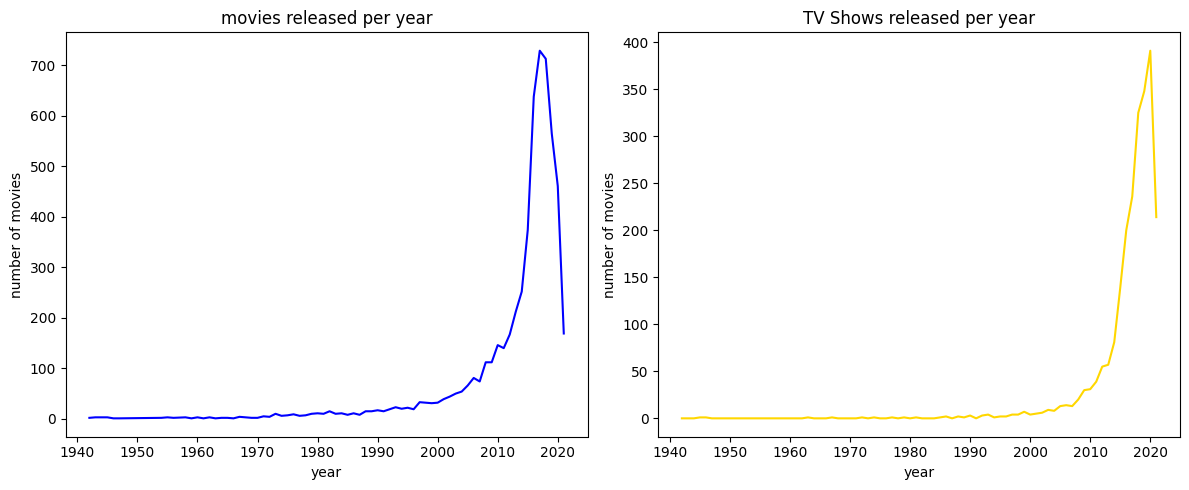

In [11]:
content_by_year = df.groupby(['release_year','type']).size().unstack().fillna(0)

fig, ax = plt.subplots(1,2, figsize=(12,5))
# Movie plot
ax[0].plot(content_by_year.index,content_by_year['Movie'], color = 'blue')
ax[0].set_title('movies released per year')
ax[0].set_xlabel('year')
ax[0].set_ylabel('number of movies')

#TV Shows plot
ax[1].plot(content_by_year.index,content_by_year['TV Show'], color = 'gold')
ax[1].set_title('TV Shows released per year')
ax[1].set_xlabel('year')
ax[1].set_ylabel('number of movies')

plt.tight_layout()
plt.savefig('Movie vs TV Shows comparison yearwise.png')
plt.show()